# **Import Library**

In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Device (Gunakan GPU jika tersedia, jika tidak kembali ke CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training akan berjalan menggunakan device: {device}")

# Path Dataset Level 1 Root
DATA_DIR = "../data/processed/level_1_root"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

Training akan berjalan menggunakan device: cuda


# **Augmentasi & Data Loader**

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standar ImageNet
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Membuat Dataset menggunakan ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

# Membuat DataLoader
BATCH_SIZE = 32
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val', 'test']
}

# Menyimpan informasi ukuran dataset dan nama kelas (organic & inorganic)
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Nama kelas di tingkat Root: {class_names}")
print(f"Jumlah data - Train: {dataset_sizes['train']}, Val: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

Nama kelas di tingkat Root: ['inorganic', 'organic']
Jumlah data - Train: 4546, Val: 896, Test: 908


# **Arsitektur Model(ViT)**

In [3]:
print("Memuat pre-trained Vision Transformer (ViT_B_16)...")
model_root = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# Mengubah lapisan terakhir (Classifier Head) agar sesuai dengan jumlah kelas kita (2 kelas)
num_features = model_root.heads.head.in_features
model_root.heads.head = nn.Linear(num_features, len(class_names))

model_root = model_root.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_root.parameters(), lr=1e-5)

Memuat pre-trained Vision Transformer (ViT_B_16)...


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\Rafif Fikri/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100%|██████████| 330M/330M [02:43<00:00, 2.12MB/s] 


# **Train Function**

In [4]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # List kosong untuk menampung riwayat performa (bisa diplot nanti)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Tiap epoch memiliki fase training dan fase validasi
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()   

            running_loss = 0.0
            running_corrects = 0

            # Iterasi melewati batch-batch data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Reset parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass & optimize hanya jika di fase training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Kalkulasi statistik akumulatif
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Simpan log history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Simpan bobot model jika performa di data validasi meningkat
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'\nTraining selesai dalam {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Akurasi Validasi Terbaik: {best_acc:4f}')

    # Muat bobot model terbaik untuk dikembalikan sebagai output fungsi
    model.load_state_dict(best_model_wts)
    return model, history

# **Train**

In [5]:
EPOCHS = 10
model_root, training_history = train_model(model_root, criterion, optimizer_ft, num_epochs=EPOCHS)

# Buat folder saved_models jika belum ada, lalu simpan bobot model terbaik
os.makedirs("../saved_models", exist_ok=True)
torch.save(model_root.state_dict(), "../saved_models/root_model_best.pth")
print("\nBobot model terbaik sukses disimpan ke '../saved_models/root_model_best.pth'")


Epoch 1/10
----------
Train Loss: 0.1093 Acc: 0.9569
Val Loss: 0.0295 Acc: 0.9933

Epoch 2/10
----------
Train Loss: 0.0175 Acc: 0.9949
Val Loss: 0.0091 Acc: 0.9978

Epoch 3/10
----------
Train Loss: 0.0121 Acc: 0.9960
Val Loss: 0.0066 Acc: 0.9989

Epoch 4/10
----------
Train Loss: 0.0063 Acc: 0.9980
Val Loss: 0.0069 Acc: 0.9967

Epoch 5/10
----------
Train Loss: 0.0040 Acc: 0.9987
Val Loss: 0.0041 Acc: 0.9989

Epoch 6/10
----------
Train Loss: 0.0023 Acc: 0.9996
Val Loss: 0.0010 Acc: 1.0000

Epoch 7/10
----------
Train Loss: 0.0005 Acc: 1.0000
Val Loss: 0.0009 Acc: 1.0000

Epoch 8/10
----------
Train Loss: 0.0004 Acc: 1.0000
Val Loss: 0.0006 Acc: 1.0000

Epoch 9/10
----------
Train Loss: 0.0138 Acc: 0.9947
Val Loss: 0.0044 Acc: 1.0000

Epoch 10/10
----------
Train Loss: 0.0029 Acc: 0.9993
Val Loss: 0.0010 Acc: 1.0000

Training selesai dalam 55m 1s
Akurasi Validasi Terbaik: 1.000000

Bobot model terbaik sukses disimpan ke '../saved_models/root_model_best.pth'


# **Visualisasi Kurva**

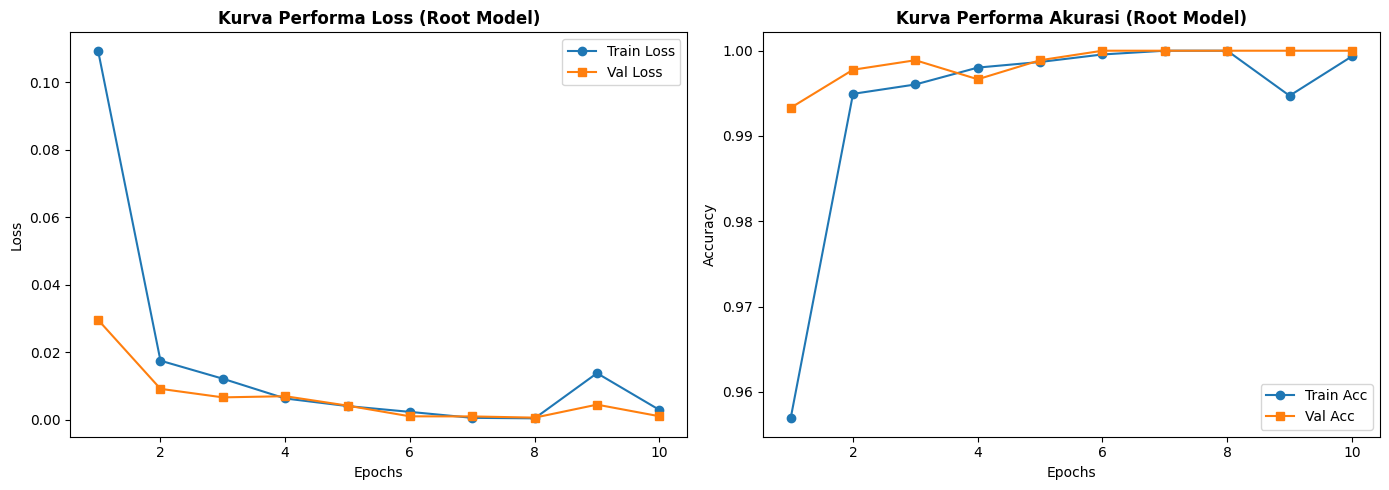

In [6]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot Kurva Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, training_history['val_loss'], label='Val Loss', marker='s')
plt.title('Kurva Performa Loss (Root Model)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Kurva Akurasi
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs_range, training_history['val_acc'], label='Val Acc', marker='s')
plt.title('Kurva Performa Akurasi (Root Model)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("../reports/figures/03_root_model_training_curves.png", dpi=300)
plt.show()

# **Confussion Matrix**

CLASSIFICATION REPORT (DATA TEST)
              precision    recall  f1-score   support

   inorganic       1.00      1.00      1.00       744
     organic       1.00      1.00      1.00       164

    accuracy                           1.00       908
   macro avg       1.00      1.00      1.00       908
weighted avg       1.00      1.00      1.00       908



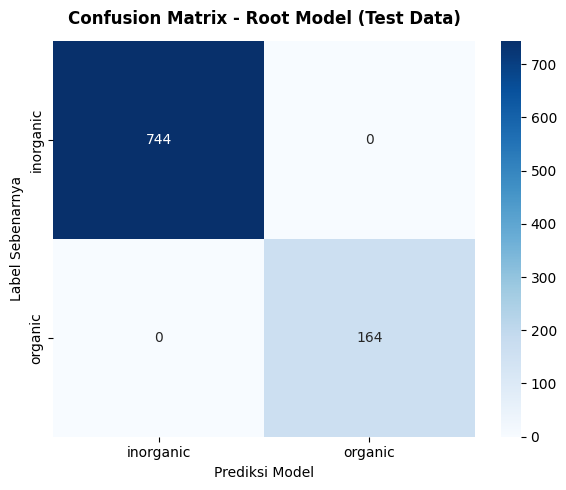

In [7]:
model_root.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model_root(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Tampilkan Classification Report resmi
print("CLASSIFICATION REPORT (DATA TEST)")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Tampilkan Confusion Matrix dalam bentuk Heatmap grafis
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Root Model (Test Data)', fontweight='bold', pad=12)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.tight_layout()
plt.savefig("../reports/figures/04_root_model_confusion_matrix.png", dpi=300)
plt.show()